
# Sentiment Analysis with Transformers (BERT)

This notebook demonstrates **sentiment analysis using a Transformer model (BERT)**.

Goal:
Classify movie reviews as **positive or negative**.

The notebook includes:
- Dataset loading : IMDB Movie Reviews (text + label 0 = negative, 1 = positive)
- Tokenization : Converting raw text into numbers (input IDs) that the model expects
- Transformer model loading : BERT with a classification head (output: 2 classes)
- Training loop : Update BERT's weights on our data using loss and optimizer
- Evaluation : Measurement of accuracy on the test data
- Prediction examples : Get positive or negative classification + confidence on our own text

Structure:
Each **code block runs normally**, and the **following markdown cell explains every line of code**.


In [6]:
# !pip install datasets evaluate accelerate

# !pip install --upgrade torch torchvision torchaudio

# !pip install transformers


# from huggingface_hub import login
# login()

In [2]:
import torch
import numpy as np
import random
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForSequenceClassification
# AutoTokenizer converts raw text into token ids and attention masks that BERT expects as input.
# AutoModelForSequenceClassification is a BERT model with an added classification head on top, which is used for fine-tuning on the sentiment analysis task.
from torch.optim import AdamW
from datasets import load_dataset

In [3]:

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)


Using device: mps


In [8]:

dataset = load_dataset("imdb")

# We take the training split, shuffle it with a fixed seed for reproducibility, and select the first 2000 samples for training.
# Similarly, we take the test split, shuffle it with the same seed, and select the first 1000 samples for testing. 
# This is done to reduce the dataset size for faster experimentation while still maintaining a representative sample of the data.
train_dataset = dataset["train"].shuffle(seed=42).select(range(2000))
test_dataset = dataset["test"].shuffle(seed=42).select(range(1000))

print(train_dataset[0])


{'text': 'There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier\'s plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, to judge, to evaluate. How about just enjoying? Funny thing too, people writing Fortier looks American but, on the other hand, arguing they prefer American series (!!!). Maybe it\'s the language, or the spirit, but I think this series is more English than American. By the way, the actors are really good and funny. The acting is not superficial at all...', 'label': 1}


In [9]:

model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)


`bert-base-uncased` was trained on lowercased text, so it treats "Great" and "great" the same. It's the base BERT model which is smaller and faster than others.

In [ ]:

def tokenize(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

# To run tokenize on every example in the training set and test set, we use the map function provided by the Hugging Face Datasets library.
# The dataset will have input_ids and attention_mask columns added, which are necessary for feeding the data into the BERT model.
train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)


# set_format is used to specify how the dataset should be returned when accessed.
# By setting type="torch", we ensure that the input_ids, attention_mask, and label columns are returned as PyTorch tensors, 
# which can be directly fed into the BERT model for training and evaluation.
train_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])
test_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])


In [11]:

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

model.to(device) # to move the model parameters to the chosen device (GPU, or MPS) if available


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8832.17it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider tr

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

`AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)` downloads the pretrained BERT weights and adds a classification head that outputs 2 logits (one per class). num_labels = 2 mean binary classification (positive or negative)

In [16]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True # randomizes the training samples at each epoch, which can help improve generalization and prevent overfitting
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=8
)


In [17]:

optimizer = AdamW(model.parameters(), lr=2e-5) # AdamW is an optimization algorithm that combines the benefits of the Adam optimizer with weight decay regularization, which can help prevent overfitting and improve generalization in deep learning models.

epochs = 2

losses = []


In [18]:

model.train()

for epoch in range(epochs):
    for batch in train_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        # Forward pass, we pass the input_ids, attention_mask, and labels to the model. 
        # The model will compute the loss based on the predictions and the true labels.
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

print("Training complete")


Training complete


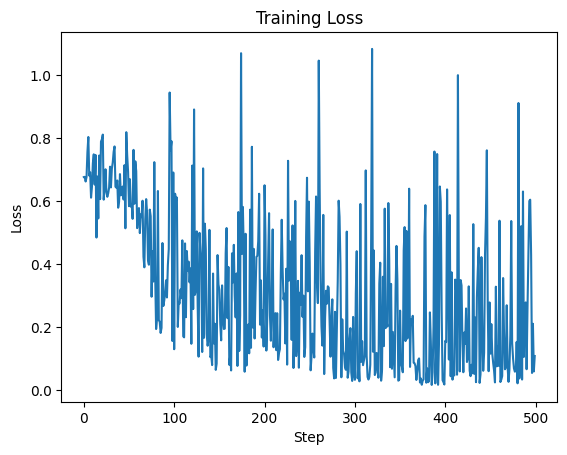

In [19]:

plt.figure()
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()


In [20]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

accuracy = correct / total
print(f"Test accuracy: {accuracy:.4f} ({correct}/{total} correct)")

Test accuracy: 0.8580 (858/1000 correct)


In [21]:
def predict_sentiment(text, model, tokenizer, device):
    """
    Predict sentiment (positive/negative) for a single text using the trained model.

    Args:
        text: Raw input string (e.g., a movie review or sentence).
        model: The trained BERT classification model.
        tokenizer: The tokenizer used during training (same as model).
        device: torch device (cuda/cpu/mps) where the model lives.

    Returns:
        predicted_label: 0 (negative) or 1 (positive).
        probability: Confidence for the predicted class (0 to 1).
    """
    model.eval()
    # Tokenize exactly like in training: same max_length and padding
    inputs = tokenizer(
        text,
        padding="max_length",
        truncation=True, # ensures that if the input text is longer than max_length, it will be truncated to fit the model's input size
        max_length=256,
        return_tensors="pt" # returns PyTorch tensors directly, which can be fed into the model without additional conversion
    )
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    # Logits are raw scores; we take the predicted class and its probability
    logits = outputs.logits
    probs = torch.softmax(logits, dim=1)
    predicted_id = torch.argmax(probs, dim=1).item()
    confidence = probs[0][predicted_id].item()

    return predicted_id, confidence


# --- Get input from the user and print the result ---
user_text = input("Enter a movie review or any sentence to analyze sentiment: ").strip()

if user_text:
    pred_label, confidence = predict_sentiment(user_text, model, tokenizer, device)
    sentiment_str = "Positive" if pred_label == 1 else "Negative"
    print(f"\nPrediction: {sentiment_str}")
    print(f"Confidence: {confidence:.2%}")
else:
    print("No text entered.")


Prediction: Positive
Confidence: 97.08%


In [27]:
# Example: predict without user input (run this if input() doesn't work in your environment)
sample_text = "I like it but I am not a big fan."
pred_label, confidence = predict_sentiment(sample_text, model, tokenizer, device)
print(f"Prediction: {'Positive' if pred_label == 1 else 'Negative'}, Confidence: {confidence:.2%}")

Prediction: Positive, Confidence: 73.70%
